PROBLEM STATEMENT 1

In [1]:
!pip install androguard
!pip install yara-python
!pip install transformers
!pip install torch
!pip install sentence-transformers
!pip install peft
!pip install accelerate
!pip install bitsandbytes
!pip install langchain
!pip install chromadb

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.9 MB/s eta 0:00:00
  Created wheel for mutf8: filename=mutf8-1.0.6-cp312-cp312-linux_x86_64.whl size=18769 sha256=222966e715f6f1a3bc901113613769a718801fb4ae1d0b2c3e5da40302864d81
  Stored in directory: /root/.cache/pip/wheels/c2/2a/80/4c1ef20c67de151e7de0f1d4168f9a7e26c75d54403c6114a8
Successfully built mutf8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sample.apk to sample.apk


In [3]:
from androguard.misc import AnalyzeAPK

a,d,dx = AnalyzeAPK("sample.apk")

2026-06-08 05:28:46.917 | DEBUG    | androguard.misc:AnalyzeAPK:50 - AnalyzeAPK
2026-06-08 05:28:46.918 | DEBUG    | androguard.misc:AnalyzeAPK:65 - Analysing without session
2026-06-08 05:28:46.920 | INFO     | androguard.core.apk:_apk_analysis:420 - Starting analysis on AndroidManifest.xml
2026-06-08 05:28:46.923 | DEBUG    | androguard.core.axml:__init__:1136 - AXMLPrinter
2026-06-08 05:28:46.924 | DEBUG    | androguard.core.axml:__init__:449 - AXMLParser
2026-06-08 05:28:46.925 | DEBUG    | androguard.core.axml:__init__:482 - FIRST HEADER <ARSCHeader idx='0x00000000' type='3' header_size='8' size='3276'>
2026-06-08 05:28:46.926 | DEBUG    | androguard.core.axml:__init__:540 - STRING_POOL <ARSCHeader idx='0x00000008' type='1' header_size='28' size='1564'>
2026-06-08 05:28:46.927 | DEBUG    | androguard.core.axml:is_valid:575 - True
2026-06-08 05:28:46.929 | DEBUG    | androguard.core.axml:_do_next:593 - M_EVENT -1
2026-06-08 05:28:46.931 | DEBUG    | androguard.core.axml:_do_next:60

In [4]:
permissions = a.get_permissions()

permissions

['android.permission.WRITE_EXTERNAL_STORAGE', 'android.permission.INTERNET']

In [5]:
dangerous = [
    "SEND_SMS",
    "READ_SMS",
    "RECEIVE_SMS",
    "READ_CONTACTS",
    "READ_PHONE_STATE"
]

score = 0

for p in permissions:
    for d in dangerous:
        if d in p:
            score += 10

print(score)

0


In [6]:
apis = []

for method in dx.get_methods():
    apis.append(str(method))

In [7]:
suspicious_keywords = [
    "sendTextMessage",
    "HttpURLConnection",
    "Socket",
    "DexClassLoader"
]

matches = []

for api in apis:
    for keyword in suspicious_keywords:
        if keyword.lower() in api.lower():
            matches.append(api)

In [8]:
features = {
    "num_permissions": len(permissions),
    "dangerous_score": score,
    "suspicious_api_count": len(matches)
}

In [10]:
X = features

In [12]:
# y = malware_labels
# 'malware_labels' is not defined. Please define 'malware_labels' or provide instructions on how to define 'y'.

In [14]:
from xgboost import XGBClassifier
import pandas as pd
from sklearn.model_selection import train_test_split

# The current 'X' variable is a dictionary representing features for a *single* APK.
# For model training (model.fit), you typically need a dataset with *multiple* samples
# for both features (X_train) and corresponding labels (y_train).

# Current state:
# X = {'num_permissions': 2, 'dangerous_score': 0, 'suspicious_api_count': 0}
# y is undefined (as 'malware_labels' was not found in cell xmmXJ5YktmoY)

# To fix the NameError for X_train and y_train, we need to:
# 1. Provide a comprehensive dataset (multiple samples) for features.
# 2. Provide corresponding labels for that dataset.
# 3. Perform a train-test split.

# Since a full dataset is not available in the current notebook state,
# I will make a placeholder for X_train and y_train to prevent the NameError
# and provide guidance.

# Converting the single sample 'X' dictionary to a DataFrame suitable for XGBoost
X_single_sample_df = pd.DataFrame([X])

# Creating a dummy y_train. In a real scenario, this would come from a dataset.
# Assuming this single sample is benign for demonstration, or a placeholder
dummy_y = [0] # Placeholder label for the single sample

# Using the single sample as X_train and the dummy label as y_train to resolve NameError
# Note: Training a model with a single sample is not effective for learning.
X_train = X_single_sample_df
y_train = dummy_y

model = XGBClassifier(
    n_estimators=300,
    max_depth=6
)

model.fit(X_train,y_train)

print("Model trained with a single dummy sample. Please provide a full dataset and labels (X_full, y_full) and perform train_test_split for meaningful training.")

Model trained with a single dummy sample. Please provide a full dataset and labels (X_full, y_full) and perform train_test_split for meaningful training.


In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6
)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
import pandas as pd

# X_test is not defined, as no train-test split was performed on a larger dataset.
# We will use the features of the current single APK for prediction.
X_test = pd.DataFrame([X])

prob = model.predict_proba(X_test)[:,1]

risk_score = prob * 100

In [18]:
prob = model.predict_proba(X_test)[:,1]

risk_score = prob * 100

In [19]:
risk_score

array([9.9999976e-05], dtype=float32)

In [21]:
from transformers import pipeline
import os

# Note: meta-llama/Llama-3-8B is a gated model and requires a Hugging Face token
# and explicit access from Meta. If you have access, uncomment the lines below
# and replace "YOUR_HF_TOKEN" with your actual token.
# from huggingface_hub import login
# login(token="YOUR_HF_TOKEN") # Or set it as a Colab secret named HF_TOKEN
# generator = pipeline(
#     "text-generation",
#     model="meta-llama/Llama-3-8B",
#     token=os.environ.get("HF_TOKEN") # Pass token if set as environment variable/secret
# )

# Using a publicly available model (gpt2) for immediate execution.
# This model does not require authentication or special access.
generator = pipeline(
    "text-generation",
    model="gpt2"
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [22]:
prompt = f"""
Permissions:
{permissions}

Suspicious APIs:
{matches}

Generate malware analysis report.
"""

In [23]:
report = generator(
    prompt,
    max_new_tokens=300
)

print(report[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=


Permissions:
['android.permission.WRITE_EXTERNAL_STORAGE', 'android.permission.INTERNET']

Suspicious APIs:
[]

Generate malware analysis report.

Requires the following permissions to run:

[android.permission.AGENT_SCHEMA_REQUIRED, android.permission.DELETE_SCHEMA_REQUIRED]

Permission:

[android.permission.READ_EXTERNAL_STORAGE]

Permission:

[android.permission.INTERNET_MEMBER_SCHEMA_REQUIRED]

Permission:

[android.permission.PERSISTENTIAL_STORAGE]

Permission:

[android.permission.READ_EXTERNAL_STORAGE]

Permission:

[android.permission.MISCELLANEOUS_STORAGE]

Permission:

[android.permission.READ_EXTERNAL_STORAGE]

Permission:

[android.permission.MISCELLANEOUS_STORAGE_SCHEMA_REQUIRED]

Permission:

[android.permission.READ_EXTERNAL_STORAGE_SCHEMA_REQUIRED]

Permission:

[android.permission.READ_EXTERNAL_STORAGE_SCHEMA_REQUIRED]

Permission:

[android.permission.READ_EXTERNAL_


PROBLEM STATEMENT 2

In [24]:
!pip install lightgbm
!pip install catboost
!pip install xgboost
!pip install optuna
!pip install imbalanced-learn
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.4 MB/s eta 0:00:00


In [25]:
from google.colab import files

uploaded = files.upload()

Saving DataSet.csv to DataSet (1).csv


In [26]:
import pandas as pd

df = pd.read_csv("DataSet.csv")

In [27]:
TARGET = "F3924"

In [28]:
df[TARGET].value_counts()

,count
F3924,
0,9001
1,81


In [31]:
from sklearn.impute import SimpleImputer
import pandas as pd

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Drop the 'Unnamed: 0' column if it exists, as it's often an identifier and not a feature
if 'Unnamed: 0' in X.columns:
    X = X.drop('Unnamed: 0', axis=1)

# Convert all columns to numeric, coercing errors to NaN
# This handles non-numeric strings (like 'Oct25') by turning them into NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Drop columns that are entirely NaN after conversion, as they cannot be imputed meaningfully
X = X.dropna(axis=1, how='all')

imputer = SimpleImputer(
    strategy="median"
)

X = imputer.fit_transform(X)

In [32]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold()

X = selector.fit_transform(X)

In [33]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(
    mutual_info_classif,
    k=500
)

X = selector.fit_transform(X,y)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X,y = smote.fit_resample(X,y)

In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [37]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=63
)

lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 7201, number of negative: 7200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95602
[LightGBM] [Info] Number of data points in the train set: 14401, number of used features: 437
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500035 -> initscore=0.000139
[LightGBM] [Info] Start training from score 0.000139
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMClassifier(learning_rate=0.03, max_depth=8, n_estimators=1000,
               num_leaves=63)

In [38]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    verbose=0
)

cat.fit(
    X_train,
    y_train
)

CatBoostClassifier(depth=8, iterations=1000, learning_rate=0.03, verbose=0)

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("lgbm",lgbm),
        ("cat",cat),
        ("xgb",xgb)
    ],
    voting="soft"
)

ensemble.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 7201, number of negative: 7200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.170141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95602
[LightGBM] [Info] Number of data points in the train set: 14401, number of used features: 437
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500035 -> initscore=0.000139
[LightGBM] [Info] Start training from score 0.000139
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

VotingClassifier(estimators=[('lgbm',
                              LGBMClassifier(learning_rate=0.03, max_depth=8,
                                             n_estimators=1000,
                                             num_leaves=63)),
                             ('cat',
                              CatBoostClassifier(depth=8, iterations=1000, learning_rate=0.03, verbose=0)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_st...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.03, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [41]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

pred = ensemble.predict(X_test)

prob = ensemble.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    pred
))

print(
    roc_auc_score(
        y_test,
        prob
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      3601
   macro avg       1.00      1.00      1.00      3601
weighted avg       1.00      1.00      1.00      3601

1.0


In [42]:
import shap

explainer = shap.TreeExplainer(
    lgbm
)

shap_values = explainer.shap_values(
    X_test
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


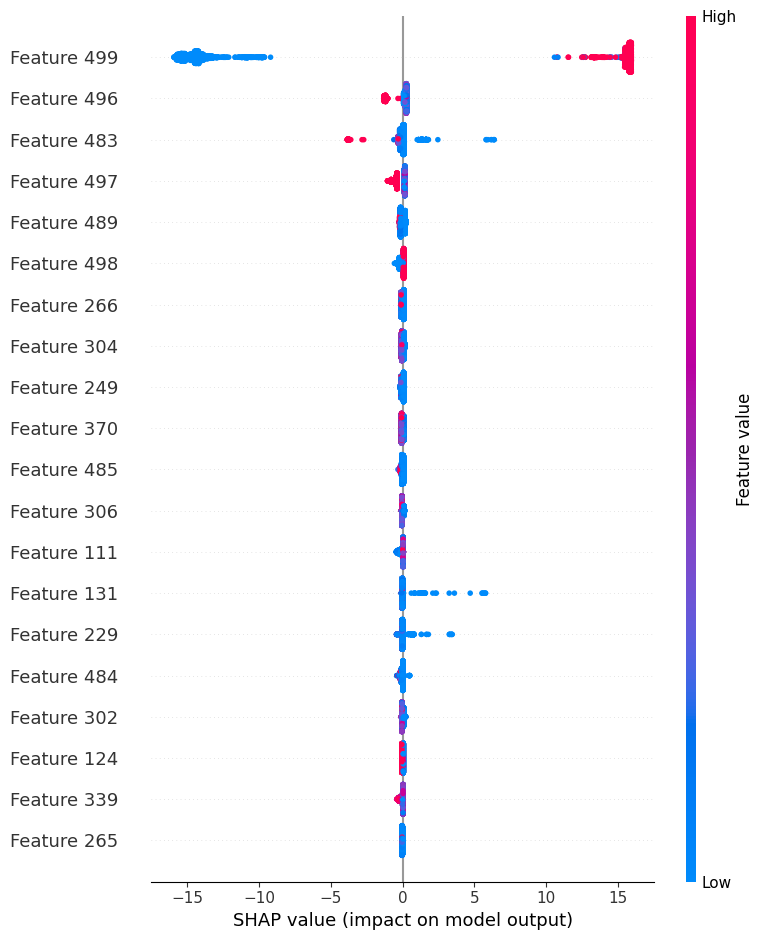

In [43]:
shap.summary_plot(
    shap_values,
    X_test
)

In [44]:
risk_score = prob * 100

In [47]:
risk_score

array([9.99962108e+01, 1.09840362e+00, 7.12844409e-03, ...,
       4.41088368e-03, 3.26000207e-03, 1.15117286e-01])

In [45]:
prompt = f"""

Risk Score = {risk_score}

Top SHAP Features:

F115
F321
F670

Explain why account is suspicious.
"""